# R² Gap Decomposition & Typological Stratification Evaluation

This notebook evaluates whether the R² monotonicity across convexity exponent α in dependency-distance convexity analysis is a **mathematical artifact** or reflects **genuine empirical signal**, and whether weak pooled convexity effects mask **typological structure**.

**Key steps:**
1. Load pre-computed per-treebank convexity statistics (residualized Cohen's d by α)
2. Compute typological stratification by word order (VSO/SVO/SOV)
3. Process raw sentences: generate random projective baselines, compute IMB costs
4. Compute pooled OLS R² for real vs. baseline data at each α
5. Bootstrap 95% CIs for ΔR² and assess monotonicity
6. Three-way verdict: mathematical artifact / weak empirical / typologically modulated

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    # scipy 1.16.3 requires Python >=3.11 (Colab's version); use 1.15.3 on Python 3.10
    _scipy = 'scipy==1.16.3' if sys.version_info >= (3, 11) else 'scipy==1.15.3'
    _pip('numpy==2.0.2', _scipy, 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import sys
import time
import random
from collections import defaultdict

import numpy as np
from scipy import stats as scipy_stats
from loguru import logger
import matplotlib.pyplot as plt

# Logging
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

# Reproducibility
random.seed(42)
np.random.seed(42)

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-e4150b-head-directionality-dependent-temporal-d/main/evaluation_iter3_r_gap_decomposi/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['treebanks'])} treebanks, {len(data['sentences_by_tb'])} with sentences")
for tb in data['treebanks']:
    n_sents = len(data['sentences_by_tb'].get(tb['tb_id'], []))
    print(f"  {tb['tb_id']}: {tb['language']} ({tb['word_order']}), {n_sents} sentences")

Loaded 8 treebanks, 8 with sentences
  akk_riao: Akkadian (other), 30 sentences
  am_att: Amharic (SOV), 30 sentences
  ar_padt: Standard Arabic (VSO), 30 sentences
  ar_pud: Standard Arabic (VSO), 30 sentences
  be_hse: Belarusian (other), 30 sentences
  bm_crb: Bambara (SOV), 30 sentences
  ca_ancora: Catalan (SVO), 30 sentences
  cop_scriptorium: Coptic (SVO), 30 sentences


In [5]:
# ============================================================
# CONFIGURATION — all tunable parameters
# ============================================================
ALPHAS = [1.0, 1.2, 1.5, 2.0, 3.0]
N_BASELINES = 2               # baselines per sentence (original: 50)
N_BOOTSTRAP = 10              # bootstrap iterations (original: 5000)
N_STABILITY_REPS = 2          # stability check reps (original: 10)
MIN_SENTENCES_PER_TB_R2 = 5   # min sentences for per-treebank R² (original: 100)
MIN_SENTENCES_FOR_POOL = 5    # min sentences to include in pooled analysis (original: 30)

## Core Functions

Dependency-distance analysis primitives: IMB profile computation, tree construction, random projective baseline generation, OLS regression, and DD feature extraction.

In [6]:
def compute_imb_profile(heads: list[int]) -> list[float]:
    """Compute IMB profile from heads array (1-indexed, 0=root)."""
    n = len(heads)
    imb = [0.0] * n
    for i in range(n):
        h = heads[i]
        if h == 0:
            continue
        dep_pos = i + 1
        head_pos = h
        s = min(dep_pos, head_pos)
        e = max(dep_pos, head_pos)
        for j in range(s, e + 1):
            imb[j - 1] += (j - s)
    return imb


def build_tree(heads: list[int]) -> tuple[int, dict]:
    """Build tree from heads (1-indexed, 0=root). Returns (root_0idx, children_dict)."""
    children = defaultdict(list)
    root = None
    for i, h in enumerate(heads):
        if h == 0:
            if root is None:
                root = i
        else:
            children[h - 1].append(i)
    return root, dict(children)


def random_projective_linearization(node: int, children_dict: dict) -> list[int]:
    """Recursively generate a random projective linearization of the subtree."""
    kids = children_dict.get(node, [])
    if not kids:
        return [node]
    left_kids, right_kids = [], []
    for kid in kids:
        if random.random() < 0.5:
            left_kids.append(kid)
        else:
            right_kids.append(kid)
    random.shuffle(left_kids)
    random.shuffle(right_kids)
    result = []
    for kid in left_kids:
        result.extend(random_projective_linearization(kid, children_dict))
    result.append(node)
    for kid in right_kids:
        result.extend(random_projective_linearization(kid, children_dict))
    return result


def generate_baseline_heads(heads: list[int]) -> list[int] | None:
    """Generate a random projective baseline linearization, returning new heads array."""
    n = len(heads)
    root, children = build_tree(heads)
    if root is None:
        return None
    lin_order = random_projective_linearization(root, children)
    if len(lin_order) != n:
        return None
    pos_map = [0] * n
    for new_pos, old_node in enumerate(lin_order):
        pos_map[old_node] = new_pos + 1
    new_heads = [0] * n
    for old_node in range(n):
        old_head = heads[old_node]
        new_pos = pos_map[old_node]
        if old_head == 0:
            new_heads[new_pos - 1] = 0
        else:
            new_heads[new_pos - 1] = pos_map[old_head - 1]
    return new_heads


def ols_regression(X: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray, float]:
    """OLS regression with intercept. Returns (beta, residuals, R²)."""
    n = X.shape[0]
    X_int = np.column_stack([np.ones(n), X])
    beta, _, _, _ = np.linalg.lstsq(X_int, y, rcond=None)
    y_pred = X_int @ beta
    resid = y - y_pred
    ss_res = float(np.sum(resid**2))
    ss_tot = float(np.sum((y - np.mean(y))**2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 1e-12 else 0.0
    return beta, resid, r2


def compute_dd_features(heads: list[int]) -> tuple[float | None, float | None, float | None, list]:
    """Compute DD list and features from heads array."""
    dd_list = []
    for i, h in enumerate(heads):
        if h == 0:
            continue
        dd_list.append(abs(i + 1 - h))
    if not dd_list:
        return None, None, None, []
    arr = np.array(dd_list, dtype=float)
    mean_dd = float(np.mean(arr))
    dd_var = float(np.var(arr, ddof=1)) if len(arr) > 1 else 0.0
    dd_skew = float(scipy_stats.skew(arr, bias=False)) if len(arr) > 2 else 0.0
    return mean_dd, dd_var, dd_skew, dd_list


def build_feature_matrix(rows: list[dict]) -> np.ndarray:
    """Extract 6-feature matrix from rows."""
    return np.array([
        [r["mean_dd"], r["dd_variance"], r["dd_skewness"],
         r["sentence_length"], r["tree_depth"], r["mean_arity"]]
        for r in rows
    ])

print("Core functions defined.")

Core functions defined.


## Step 1: Load Treebank Metadata & Typological Stratification

Parse pre-computed per-treebank convexity statistics and compute stratification of residualized Cohen's d by word order (VSO/SVO/SOV) using Kruskal-Wallis tests.

In [7]:
# Parse treebank metadata from loaded data
treebanks = []
for tb_meta in data["treebanks"]:
    resid_d = tb_meta.get("resid_d_by_alpha", {})
    raw_d = tb_meta.get("raw_d_by_alpha", {})
    wo = tb_meta.get("word_order", "other")
    if wo in ("", "None", "No dominant order", "unknown"):
        wo = "other"
    treebanks.append({
        "tb_id": tb_meta["tb_id"],
        "language": tb_meta.get("language", ""),
        "word_order": wo,
        "family": tb_meta.get("family", "unknown"),
        "n_sentences": tb_meta.get("n_sentences", 0),
        "resid_d": resid_d,
        "raw_d": raw_d,
    })

tb_info = {tb["tb_id"]: tb for tb in treebanks}
logger.info(f"Loaded {len(treebanks)} treebanks")
for tb in treebanks:
    logger.info(f"  {tb['tb_id']}: {tb['language']} ({tb['word_order']})")

01:55:15|INFO   |Loaded 8 treebanks


01:55:15|INFO   |  akk_riao: Akkadian (other)


01:55:15|INFO   |  am_att: Amharic (SOV)


01:55:15|INFO   |  ar_padt: Standard Arabic (VSO)


01:55:15|INFO   |  ar_pud: Standard Arabic (VSO)


01:55:15|INFO   |  be_hse: Belarusian (other)


01:55:15|INFO   |  bm_crb: Bambara (SOV)


01:55:15|INFO   |  ca_ancora: Catalan (SVO)


01:55:15|INFO   |  cop_scriptorium: Coptic (SVO)


In [8]:
def compute_stratification(treebanks, alphas):
    """Compute typological stratification of convexity evidence."""
    logger.info("Computing typological stratification")
    by_wo = defaultdict(list)
    for tb in treebanks:
        by_wo[tb["word_order"]].append(tb)
    for wo, tbs in sorted(by_wo.items()):
        logger.info(f"  {wo}: {len(tbs)} treebanks")

    results = {"by_word_order": {}, "kruskal_wallis": {}, "spearman_within_wo": {},
               "ranking_check": {}, "raw_by_word_order": {}, "raw_kruskal_wallis": {}}

    for a in alphas:
        akey = f"{a:.1f}"
        # Residualized d
        wo_stats = {}
        for wo, tbs in by_wo.items():
            ds = [tb["resid_d"].get(akey, 0.0) for tb in tbs]
            arr = np.array(ds)
            wo_stats[wo] = {
                "n": len(ds), "median_d": float(np.median(arr)),
                "mean_d": float(np.mean(arr)),
                "std_d": float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0,
                "iqr_25": float(np.percentile(arr, 25)),
                "iqr_75": float(np.percentile(arr, 75)),
                "values": ds,
            }
        results["by_word_order"][akey] = wo_stats

        # Kruskal-Wallis across VSO/SVO/SOV
        groups_kw, group_labels = [], []
        for wo_label in ["VSO", "SVO", "SOV"]:
            if wo_label in wo_stats and wo_stats[wo_label]["n"] >= 2:
                groups_kw.append(wo_stats[wo_label]["values"])
                group_labels.append(wo_label)
        if len(groups_kw) >= 2:
            try:
                h_stat, p_val = scipy_stats.kruskal(*groups_kw)
                results["kruskal_wallis"][akey] = {"h_statistic": float(h_stat), "p_value": float(p_val), "groups": group_labels}
            except Exception:
                results["kruskal_wallis"][akey] = {"h_statistic": 0.0, "p_value": 1.0, "groups": group_labels}
        else:
            results["kruskal_wallis"][akey] = {"h_statistic": 0.0, "p_value": 1.0, "groups": group_labels}

        # Check ranking: VSO > SVO > SOV median d
        ranking_ok = True
        for wo_a, wo_b in [("VSO", "SVO"), ("SVO", "SOV")]:
            if wo_a in wo_stats and wo_b in wo_stats:
                if wo_stats[wo_a]["median_d"] <= wo_stats[wo_b]["median_d"]:
                    ranking_ok = False
            else:
                ranking_ok = False
        results["ranking_check"][akey] = ranking_ok

        # Raw d
        raw_wo_stats = {}
        for wo, tbs in by_wo.items():
            ds = [tb["raw_d"].get(akey, 0.0) for tb in tbs]
            arr = np.array(ds)
            raw_wo_stats[wo] = {"n": len(ds), "median_d": float(np.median(arr)),
                                "mean_d": float(np.mean(arr)),
                                "std_d": float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0, "values": ds}
        results["raw_by_word_order"][akey] = raw_wo_stats
        raw_groups_kw, raw_group_labels = [], []
        for wo_label in ["VSO", "SVO", "SOV"]:
            if wo_label in raw_wo_stats and raw_wo_stats[wo_label]["n"] >= 2:
                raw_groups_kw.append(raw_wo_stats[wo_label]["values"])
                raw_group_labels.append(wo_label)
        if len(raw_groups_kw) >= 2:
            try:
                h_stat, p_val = scipy_stats.kruskal(*raw_groups_kw)
                results["raw_kruskal_wallis"][akey] = {"h_statistic": float(h_stat), "p_value": float(p_val)}
            except Exception:
                results["raw_kruskal_wallis"][akey] = {"h_statistic": 0.0, "p_value": 1.0}
        else:
            results["raw_kruskal_wallis"][akey] = {"h_statistic": 0.0, "p_value": 1.0}

    # Spearman within each word-order group
    for wo in by_wo:
        medians = [results["by_word_order"][f"{a:.1f}"].get(wo, {}).get("median_d", 0.0) for a in alphas]
        if len(medians) >= 3:
            rho, p = scipy_stats.spearmanr(alphas, medians)
            results["spearman_within_wo"][wo] = {
                "rho": float(rho) if not np.isnan(rho) else 0.0,
                "p_value": float(p) if not np.isnan(p) else 1.0,
            }
    return results

stratification = compute_stratification(treebanks, ALPHAS)
logger.info("Stratification complete")

01:55:15|INFO   |Computing typological stratification


01:55:15|INFO   |  SOV: 2 treebanks


01:55:15|INFO   |  SVO: 2 treebanks


01:55:15|INFO   |  VSO: 2 treebanks


01:55:15|INFO   |  other: 2 treebanks


01:55:15|INFO   |Stratification complete


## Step 2: Process Sentences for R² Gap

For each treebank, compute IMB profiles and convexity costs for real sentences, then generate random projective baselines and compute the same features. This enables comparing R² between real and baseline data.

In [9]:
def process_treebank_r2(tb_id, sentences, n_baselines, alphas):
    """Per-treebank processing for R² gap analysis (sequential version for notebook)."""
    rng_seed = sum(ord(c) * (i + 1) for i, c in enumerate(tb_id)) % (2**31)
    random.seed(rng_seed)
    np.random.seed(rng_seed % (2**32))

    real_rows = []
    baseline_rows = []
    n_skipped = 0

    for sent in sentences:
        heads = sent["heads"]
        if len(heads) < 3:
            n_skipped += 1
            continue

        # REAL sentence features + costs
        imb = compute_imb_profile(heads)
        imb_arr = np.array(imb)
        real_row = {
            "mean_dd": sent["mean_dd"], "dd_variance": sent["dd_variance"],
            "dd_skewness": sent["dd_skewness"], "sentence_length": sent["sentence_length"],
            "tree_depth": sent["tree_depth"], "mean_arity": sent["mean_arity"],
        }
        for a in alphas:
            real_row[f"cost_{a:.1f}"] = float(np.sum(np.power(imb_arr, a)))
        real_rows.append(real_row)

        # Generate N baselines, randomly select 1 for R² analysis
        baseline_data = []
        for _ in range(n_baselines):
            try:
                bh = generate_baseline_heads(heads)
            except RecursionError:
                continue
            if bh is None:
                continue
            b_mean_dd, b_dd_var, b_dd_skew, _ = compute_dd_features(bh)
            if b_mean_dd is None:
                continue
            b_imb = compute_imb_profile(bh)
            b_arr = np.array(b_imb)
            b_row = {
                "mean_dd": b_mean_dd, "dd_variance": b_dd_var, "dd_skewness": b_dd_skew,
                "sentence_length": sent["sentence_length"],
                "tree_depth": sent["tree_depth"], "mean_arity": sent["mean_arity"],
            }
            for a in alphas:
                b_row[f"cost_{a:.1f}"] = float(np.sum(np.power(b_arr, a)))
            baseline_data.append(b_row)

        if baseline_data:
            baseline_rows.append(random.choice(baseline_data))
        else:
            n_skipped += 1

    return tb_id, real_rows, baseline_rows


# Process all treebanks sequentially (no multiprocessing in notebook)
sentences_by_tb = data["sentences_by_tb"]
valid_tbs = {k: v for k, v in sentences_by_tb.items() if len(v) >= MIN_SENTENCES_FOR_POOL}
logger.info(f"Treebanks with >={MIN_SENTENCES_FOR_POOL} sentences: {len(valid_tbs)}")

per_tb_results = {}
t_proc = time.time()
for tb_id, sents in valid_tbs.items():
    ret_id, real_rows, baseline_rows = process_treebank_r2(tb_id, sents, N_BASELINES, ALPHAS)
    per_tb_results[ret_id] = {"real": real_rows, "baseline": baseline_rows}
    logger.info(f"  {ret_id}: {len(real_rows)} real, {len(baseline_rows)} baseline")

total_real = sum(len(v["real"]) for v in per_tb_results.values())
total_base = sum(len(v["baseline"]) for v in per_tb_results.values())
logger.info(f"Processing done: {total_real} real, {total_base} baseline sentences in {time.time()-t_proc:.1f}s")

01:55:15|INFO   |Treebanks with >=5 sentences: 8


01:55:16|INFO   |  ca_ancora: 30 real, 30 baseline


01:55:16|INFO   |  cop_scriptorium: 30 real, 30 baseline


01:55:16|INFO   |  am_att: 30 real, 30 baseline


01:55:16|INFO   |  bm_crb: 30 real, 30 baseline


01:55:16|INFO   |  ar_padt: 30 real, 30 baseline


01:55:16|INFO   |  ar_pud: 30 real, 30 baseline


01:55:16|INFO   |  akk_riao: 30 real, 30 baseline


01:55:16|INFO   |  be_hse: 30 real, 30 baseline


01:55:16|INFO   |Processing done: 240 real, 240 baseline sentences in 0.2s


## Step 3: Pooled R² Gap Analysis

Compute pooled OLS R² for real vs. baseline data at each α using 6 features (DD moments + tree properties). The key metric is ΔR² = R²_real - R²_baseline at each exponent.

In [10]:
def compute_pooled_r2(per_tb_results, alphas):
    """Compute pooled R² for real vs baseline across all treebanks."""
    logger.info("Computing pooled R² gap analysis")
    all_real, all_baseline = [], []
    for tb_id in sorted(per_tb_results):
        all_real.extend(per_tb_results[tb_id]["real"])
        all_baseline.extend(per_tb_results[tb_id]["baseline"])
    logger.info(f"  Pooled: {len(all_real)} real, {len(all_baseline)} baseline sentences")

    X_real = build_feature_matrix(all_real)
    X_baseline = build_feature_matrix(all_baseline)
    X_real_dd = X_real[:, :3]
    X_baseline_dd = X_baseline[:, :3]

    r2_results = {}
    for a in alphas:
        akey = f"{a:.1f}"
        y_real = np.array([r[f"cost_{akey}"] for r in all_real])
        y_base = np.array([r[f"cost_{akey}"] for r in all_baseline])
        _, _, r2_real = ols_regression(X_real, y_real)
        _, _, r2_base = ols_regression(X_baseline, y_base)
        _, _, r2_real_dd = ols_regression(X_real_dd, y_real)
        _, _, r2_base_dd = ols_regression(X_baseline_dd, y_base)
        r2_results[akey] = {
            "r2_real": r2_real, "r2_baseline": r2_base,
            "delta_r2": r2_real - r2_base,
            "r2_real_dd_only": r2_real_dd, "r2_baseline_dd_only": r2_base_dd,
            "delta_r2_dd_only": r2_real_dd - r2_base_dd,
        }
        logger.info(f"  α={akey}: R²_real={r2_real:.4f}, R²_base={r2_base:.4f}, ΔR²={r2_real - r2_base:.4f}")

    deltas = [r2_results[f"{a:.1f}"]["delta_r2"] for a in alphas]
    rho_gap, p_gap = scipy_stats.spearmanr(alphas, deltas)
    r2_results["spearman_gap_vs_alpha"] = {
        "rho": float(rho_gap) if not np.isnan(rho_gap) else 0.0,
        "p_value": float(p_gap) if not np.isnan(p_gap) else 1.0,
    }
    return r2_results

r2_results = compute_pooled_r2(per_tb_results, ALPHAS)

01:55:16|INFO   |Computing pooled R² gap analysis


01:55:16|INFO   |  Pooled: 240 real, 240 baseline sentences


01:55:16|INFO   |  α=1.0: R²_real=0.9703, R²_base=0.9805, ΔR²=-0.0102


01:55:16|INFO   |  α=1.2: R²_real=0.9588, R²_base=0.9649, ΔR²=-0.0062


01:55:16|INFO   |  α=1.5: R²_real=0.9352, R²_base=0.9343, ΔR²=0.0010


01:55:16|INFO   |  α=2.0: R²_real=0.8875, R²_base=0.8794, ΔR²=0.0081


01:55:16|INFO   |  α=3.0: R²_real=0.8037, R²_base=0.7949, ΔR²=0.0088


## Step 4: Bootstrap, Stability & Per-Treebank R²

Bootstrap 95% CIs for ΔR² by resampling treebanks. Run stability checks on baseline R². Compute per-treebank R² gap for treebanks with sufficient sentences.

In [11]:
def stability_check(per_tb_results, alphas, n_reps=N_STABILITY_REPS):
    """Repeat baseline R² with subsampled treebanks for stability."""
    logger.info(f"Running {n_reps}-rep stability check")
    tb_ids = list(per_tb_results.keys())
    r2_base_samples = {f"{a:.1f}": [] for a in alphas}
    rng = np.random.RandomState(42)
    for rep in range(n_reps):
        n_sample = max(int(len(tb_ids) * 0.8), 1)
        sampled = rng.choice(tb_ids, size=n_sample, replace=False)
        base_pool = []
        for tb in sampled:
            base_pool.extend(per_tb_results[tb]["baseline"])
        if len(base_pool) < 5:
            continue
        X_b = build_feature_matrix(base_pool)
        for a in alphas:
            akey = f"{a:.1f}"
            y_b = np.array([r[f"cost_{akey}"] for r in base_pool])
            _, _, r2_b = ols_regression(X_b, y_b)
            r2_base_samples[akey].append(r2_b)
    stability = {}
    for a in alphas:
        akey = f"{a:.1f}"
        samples = r2_base_samples[akey]
        if samples:
            stability[akey] = {"mean_r2_baseline": float(np.mean(samples)),
                               "std_r2_baseline": float(np.std(samples)),
                               "stable": float(np.std(samples)) < 0.05}
        else:
            stability[akey] = {"mean_r2_baseline": 0.0, "std_r2_baseline": 0.0, "stable": True}
    return stability


def bootstrap_r2_gap(per_tb_results, alphas, n_boot=N_BOOTSTRAP):
    """Bootstrap 95% CI for ΔR²(α) by resampling treebanks."""
    logger.info(f"Running {n_boot}-iteration bootstrap")
    tb_ids = list(per_tb_results.keys())
    n_tbs = len(tb_ids)
    boot_gaps = {f"{a:.1f}": [] for a in alphas}
    rng = np.random.RandomState(42)
    for b in range(n_boot):
        sampled_indices = rng.choice(n_tbs, size=n_tbs, replace=True)
        sampled_tbs = [tb_ids[i] for i in sampled_indices]
        real_pool, base_pool = [], []
        for tb in sampled_tbs:
            real_pool.extend(per_tb_results[tb]["real"])
            base_pool.extend(per_tb_results[tb]["baseline"])
        if len(real_pool) < 5 or len(base_pool) < 5:
            continue
        X_r = build_feature_matrix(real_pool)
        X_b = build_feature_matrix(base_pool)
        for a in alphas:
            akey = f"{a:.1f}"
            y_r = np.array([r[f"cost_{akey}"] for r in real_pool])
            y_b = np.array([r[f"cost_{akey}"] for r in base_pool])
            _, _, r2_r = ols_regression(X_r, y_r)
            _, _, r2_b = ols_regression(X_b, y_b)
            boot_gaps[akey].append(r2_r - r2_b)
    boot_results = {}
    for a in alphas:
        akey = f"{a:.1f}"
        gaps = np.array(boot_gaps[akey])
        if len(gaps) > 0:
            boot_results[akey] = {"ci_2_5": float(np.percentile(gaps, 2.5)),
                                  "ci_50": float(np.percentile(gaps, 50)),
                                  "ci_97_5": float(np.percentile(gaps, 97.5)),
                                  "mean": float(np.mean(gaps)), "std": float(np.std(gaps))}
        else:
            boot_results[akey] = {"ci_2_5": 0.0, "ci_50": 0.0, "ci_97_5": 0.0, "mean": 0.0, "std": 0.0}
    n_valid = len(boot_gaps[f"{alphas[0]:.1f}"])
    n_monotonic = 0
    for i in range(n_valid):
        gaps_at_i = [boot_gaps[f"{a:.1f}"][i] for a in alphas]
        if all(gaps_at_i[j+1] >= gaps_at_i[j] for j in range(len(gaps_at_i)-1)):
            n_monotonic += 1
    boot_results["prop_monotonic"] = n_monotonic / n_valid if n_valid > 0 else 0.0
    return boot_results


def compute_per_treebank_r2(per_tb_results, treebank_info, alphas):
    """Compute per-treebank R² gap for treebanks with sufficient sentences."""
    logger.info("Computing per-treebank R²")
    per_tb_r2 = {}
    for tb_id in sorted(per_tb_results):
        real = per_tb_results[tb_id]["real"]
        base = per_tb_results[tb_id]["baseline"]
        if len(real) < MIN_SENTENCES_PER_TB_R2 or len(base) < MIN_SENTENCES_PER_TB_R2:
            continue
        X_r = build_feature_matrix(real)
        X_b = build_feature_matrix(base)
        tb_r2 = {}
        for a in alphas:
            akey = f"{a:.1f}"
            y_r = np.array([r[f"cost_{akey}"] for r in real])
            y_b = np.array([r[f"cost_{akey}"] for r in base])
            _, _, r2_r = ols_regression(X_r, y_r)
            _, _, r2_b = ols_regression(X_b, y_b)
            tb_r2[akey] = {"r2_real": r2_r, "r2_baseline": r2_b, "delta_r2": r2_r - r2_b}
        per_tb_r2[tb_id] = tb_r2
    logger.info(f"  Per-treebank R² computed for {len(per_tb_r2)} treebanks")
    by_wo = defaultdict(list)
    for tb_id, r2_data in per_tb_r2.items():
        wo = treebank_info.get(tb_id, {}).get("word_order", "other")
        by_wo[wo].append(r2_data)
    wo_median_delta = {}
    for wo, r2_list in by_wo.items():
        wo_median_delta[wo] = {}
        for a in alphas:
            akey = f"{a:.1f}"
            deltas = [r[akey]["delta_r2"] for r in r2_list]
            wo_median_delta[wo][akey] = {"n": len(deltas), "median_delta_r2": float(np.median(deltas)),
                                         "mean_delta_r2": float(np.mean(deltas))}
    return {"per_treebank": per_tb_r2, "by_word_order": wo_median_delta}

stability = stability_check(per_tb_results, ALPHAS)
bootstrap = bootstrap_r2_gap(per_tb_results, ALPHAS)
per_tb_r2_data = compute_per_treebank_r2(per_tb_results, tb_info, ALPHAS)
logger.info("Bootstrap, stability, per-treebank R² complete")

01:55:16|INFO   |Running 2-rep stability check


01:55:16|INFO   |Running 10-iteration bootstrap


01:55:16|INFO   |Computing per-treebank R²


01:55:16|INFO   |  Per-treebank R² computed for 8 treebanks


01:55:16|INFO   |Bootstrap, stability, per-treebank R² complete


## Step 5: Verdicts

Three-way assessment: (1) Is the R² pattern a mathematical artifact? (2) Is the empirical signal merely weak? (3) Is convexity typologically modulated matching the LLF pattern?

In [12]:
def compute_verdicts(r2_results, stratification, alphas):
    """Compute 3-way verdict: mathematical artifact, weak empirical, or typologically modulated."""
    gap_values = [r2_results[f"{a:.1f}"]["delta_r2"] for a in alphas]
    gap_range = max(gap_values) - min(gap_values)
    rho_gap = r2_results["spearman_gap_vs_alpha"]["rho"]

    # Verdict 1: Mathematical artifact?
    verdict_mathematical = (abs(rho_gap) < 0.8) and (gap_range < 0.05)

    # Verdict 2: Weak empirical signal?
    verdict_weak_empirical = (rho_gap > 0.8) and (max(gap_values) < 0.10)

    # Verdict 3: Typologically modulated?
    any_kw_sig = any(
        stratification["kruskal_wallis"].get(f"{a:.1f}", {}).get("p_value", 1.0) < 0.05
        for a in alphas if a >= 1.5
    )
    ranking_matches = all(
        stratification["ranking_check"].get(f"{a:.1f}", False)
        for a in alphas if a >= 1.5
    )
    verdict_typological = any_kw_sig and ranking_matches

    verdicts = {
        "mathematical_artifact": verdict_mathematical,
        "weak_empirical": verdict_weak_empirical,
        "typologically_modulated": verdict_typological,
        "gap_range": gap_range,
        "gap_rho": rho_gap,
        "gap_values": gap_values,
        "max_gap": max(gap_values),
    }

    logger.info("Verdicts:")
    logger.info(f"  Mathematical artifact: {verdict_mathematical} (|rho|={abs(rho_gap):.3f}, range={gap_range:.4f})")
    logger.info(f"  Weak empirical: {verdict_weak_empirical} (rho={rho_gap:.3f}, max_gap={max(gap_values):.4f})")
    logger.info(f"  Typologically modulated: {verdict_typological} (KW sig={any_kw_sig}, ranking={ranking_matches})")
    return verdicts

verdicts = compute_verdicts(r2_results, stratification, ALPHAS)

01:55:16|INFO   |Verdicts:


01:55:16|INFO   |  Mathematical artifact: False (|rho|=1.000, range=0.0190)


01:55:16|INFO   |  Weak empirical: True (rho=1.000, max_gap=0.0088)


01:55:16|INFO   |  Typologically modulated: False (KW sig=False, ranking=False)


## Results & Visualization

Summary table of R² gap metrics, bootstrap CIs, and verdicts. Plot ΔR² as a function of α with bootstrap confidence intervals, and show stratified residualized Cohen's d by word order.

R² GAP DECOMPOSITION RESULTS
Alpha    R²_real    R²_base    Delta_R²   Boot CI 2.5%   Boot CI 97.5% 
----------------------------------------------------------------------
1.0      0.9703     0.9805     -0.0102    -0.0235        0.0111        
1.2      0.9588     0.9649     -0.0062    -0.0264        0.0117        
1.5      0.9352     0.9343     0.0010     -0.0365        0.0159        
2.0      0.8875     0.8794     0.0081     -0.0698        0.0285        
3.0      0.8037     0.7949     0.0088     -0.1601        0.0632        

Spearman rho (Delta_R² vs alpha): 1.0000 (p=0.0000)
Bootstrap monotonicity proportion: 0.200

VERDICTS
  Mathematical artifact: False (|rho|=1.000, range=0.0190)
  Weak empirical:       True (rho=1.000, max_gap=0.0088)
  Typologically modulated: False

KRUSKAL-WALLIS (word-order stratification)
  alpha=1.0: H=3.714, p=0.1561 
  alpha=1.2: H=2.571, p=0.2765 
  alpha=1.5: H=2.571, p=0.2765 
  alpha=2.0: H=3.429, p=0.1801 
  alpha=3.0: H=2.000, p=0.3679 


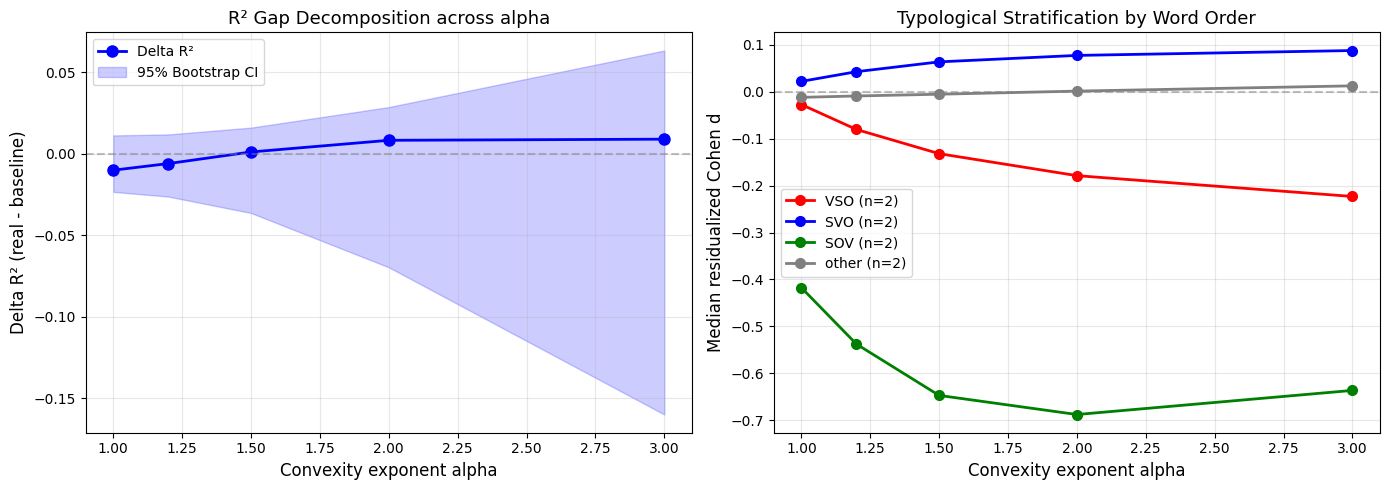


Plot saved to results_plot.png


In [13]:
# ============================================================
# RESULTS TABLE
# ============================================================
print("=" * 70)
print("R² GAP DECOMPOSITION RESULTS")
print("=" * 70)
print(f"{'Alpha':<8} {'R²_real':<10} {'R²_base':<10} {'Delta_R²':<10} {'Boot CI 2.5%':<14} {'Boot CI 97.5%':<14}")
print("-" * 70)
for a in ALPHAS:
    akey = f"{a:.1f}"
    r2 = r2_results.get(akey, {})
    boot = bootstrap.get(akey, {})
    print(f"{akey:<8} {r2.get('r2_real',0):<10.4f} {r2.get('r2_baseline',0):<10.4f} "
          f"{r2.get('delta_r2',0):<10.4f} {boot.get('ci_2_5',0):<14.4f} {boot.get('ci_97_5',0):<14.4f}")

sp = r2_results.get("spearman_gap_vs_alpha", {})
print(f"\nSpearman rho (Delta_R² vs alpha): {sp.get('rho', 0):.4f} (p={sp.get('p_value', 1):.4f})")
print(f"Bootstrap monotonicity proportion: {bootstrap.get('prop_monotonic', 0):.3f}")

print("\n" + "=" * 70)
print("VERDICTS")
print("=" * 70)
print(f"  Mathematical artifact: {verdicts['mathematical_artifact']} "
      f"(|rho|={abs(verdicts['gap_rho']):.3f}, range={verdicts['gap_range']:.4f})")
print(f"  Weak empirical:       {verdicts['weak_empirical']} "
      f"(rho={verdicts['gap_rho']:.3f}, max_gap={verdicts['max_gap']:.4f})")
print(f"  Typologically modulated: {verdicts['typologically_modulated']}")

print("\n" + "=" * 70)
print("KRUSKAL-WALLIS (word-order stratification)")
print("=" * 70)
for a in ALPHAS:
    akey = f"{a:.1f}"
    kw = stratification["kruskal_wallis"].get(akey, {})
    sig = "*" if kw.get("p_value", 1) < 0.05 else ""
    print(f"  alpha={akey}: H={kw.get('h_statistic',0):.3f}, p={kw.get('p_value',1):.4f} {sig}")

# ============================================================
# PLOT 1: Delta R² vs Alpha with bootstrap CIs
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
deltas = [r2_results[f"{a:.1f}"]["delta_r2"] for a in ALPHAS]
ci_lo = [bootstrap.get(f"{a:.1f}", {}).get("ci_2_5", 0) for a in ALPHAS]
ci_hi = [bootstrap.get(f"{a:.1f}", {}).get("ci_97_5", 0) for a in ALPHAS]
ax.plot(ALPHAS, deltas, 'bo-', linewidth=2, markersize=8, label='Delta R²')
ax.fill_between(ALPHAS, ci_lo, ci_hi, alpha=0.2, color='blue', label='95% Bootstrap CI')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Convexity exponent alpha', fontsize=12)
ax.set_ylabel('Delta R² (real - baseline)', fontsize=12)
ax.set_title('R² Gap Decomposition across alpha', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# PLOT 2: Stratified median residualized d by word order
ax = axes[1]
wo_colors = {"VSO": "red", "SVO": "blue", "SOV": "green", "other": "gray"}
for wo in ["VSO", "SVO", "SOV", "other"]:
    medians = []
    for a in ALPHAS:
        akey = f"{a:.1f}"
        wo_data = stratification["by_word_order"].get(akey, {}).get(wo, {})
        medians.append(wo_data.get("median_d", 0.0))
    if any(m != 0 for m in medians):
        ax.plot(ALPHAS, medians, 'o-', color=wo_colors.get(wo, "black"),
                linewidth=2, markersize=7, label=f'{wo} (n={stratification["by_word_order"].get("1.0",{}).get(wo,{}).get("n",0)})')

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Convexity exponent alpha', fontsize=12)
ax.set_ylabel('Median residualized Cohen d', fontsize=12)
ax.set_title('Typological Stratification by Word Order', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results_plot.png', dpi=100, bbox_inches='tight')
plt.show()
print("\nPlot saved to results_plot.png")